### Provide violin plot for visualizing the fetalization genes that intersect with GWAS

In [1]:
library(dplyr)
library(ggplot2)
library(DESeq2)
library(tidyr)
library(tidyverse)
library(tibble)
library(ggrepel)
library(clusterProfiler) 
library(org.Hs.eg.db)
library(viridis)
`%notin%` <- Negate(`%in%`)
library(dendextend)
library(limma)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics


Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:dplyr’:

    combine, intersect, setdiff, union


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, intersect, is.unsorted, lapply, Map, mapply,
    match, mget, order, paste, pmax, pmax.int, pmin, pmin.int,
    Position, rank, rbind, Reduce, rownames, sapply, setdiff, table,
    tapply, union, unique, unsplit, which.max, which.min



Attaching packag

In [2]:
plot_gene_violin <- function(dds, gene, x_col, log_transform = TRUE, 
                             pseudocount = 1, point_size = 1.2) {
  
    # extract normalized counts
    norm_counts <- counts(dds, normalized = TRUE)[gene, ]
  
    df <- as.data.frame(colData(dds)) %>%
    mutate(raw_expression = norm_counts) %>%
    filter(raw_expression > 0) %>%   # ⬅️ drop zeros
    mutate(
      expression = if (log_transform)
        log2(raw_expression + pseudocount)
      else raw_expression
    )

  p1 <- ggplot(df, aes_string(x = x_col, y = "expression")) +
    geom_violin(trim = FALSE, fill = "grey85", color = "black") +
    geom_boxplot(width = 0.2, outlier.shape = NA, fill = "white", color = "black") +
    geom_jitter(width = 0.15, size = point_size, alpha = 0.6) +
    theme_bw() +
    labs(x = x_col, y = ifelse(log_transform, paste0("log2(normalized counts + ", pseudocount, ")"),
                               "Normalized counts"),
      title = gene) +
    theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, color = "black"),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black"), strip.background = element_blank())

    print(p1)
        
    return(df)    
}

In [3]:
run_filtered_DESeq <- function(count_matrix, metadata, metadata_categories) {
    # Run filtered DESeq2 (filtered to specific disease categories)
    
    count_matrix <- t(count_matrix)
    colnames(count_matrix) <- metadata$donor_id
    metadata$disease_age_status <- paste0(metadata$disease, "-", metadata$age_status)

    # perform filtering
    filt_metadata <- metadata[metadata$disease_age_status %in% metadata_categories, ]
    filt_count_matrix <- count_matrix[, filt_metadata$donor_id]

    dds <- DESeqDataSetFromMatrix(countData = filt_count_matrix,
                              colData = filt_metadata,
                              design = ~ tech_plus_study + sex + age_group + sex:age_group)

    # perform normalization
    dds <- estimateSizeFactors(dds)
    return(dds)
} 

In [4]:
plots_dir <- "plots/"

In [5]:
#pseudobulked_res_dir <- "/mnt/data1/william/human_heart_project/Final_manuscript_analysis/RNA/aggregated_analysis/v3_pseudobulked_analysis/disease_DEG_analysis/non_binarized/pydeseq2_results/"

### ADAMTS7 in endothelial cells

In [6]:
Endo_count_matrix <- read.csv("../../../../RNA/aggregated_analysis/v3_pseudobulked_analysis/raw_pseudobulked_matrices/Endothelial_count_matrix.csv", row.names = 1)
Endo_metadata <- read.csv("../../../../RNA/aggregated_analysis/v3_pseudobulked_analysis/raw_pseudobulked_matrices/Endothelial_metadata.csv", row.names = 1)

In [7]:
Endo_dds <- run_filtered_DESeq(count_matrix = Endo_count_matrix, metadata = Endo_metadata, 
                               metadata_categories = c("ND-fetal", "ND-postnatal", "HCM-postnatal") )

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


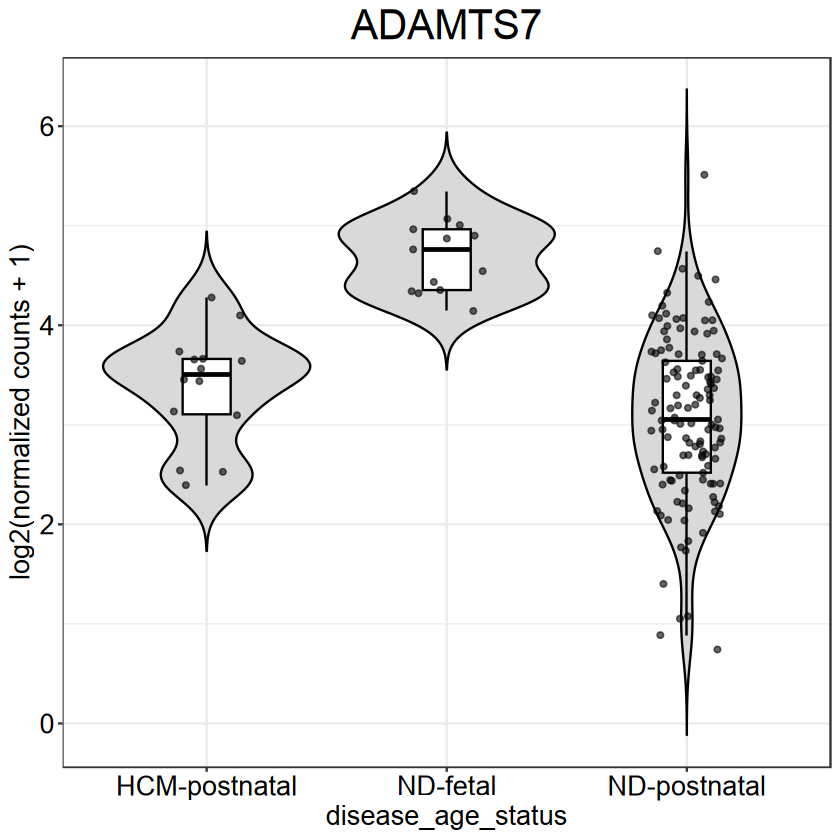

In [8]:
gene_name = "ADAMTS7"
Endo_df = plot_gene_violin(Endo_dds, gene = gene_name, x_col = "disease_age_status")

Warning message:
“Removed 40 rows containing missing values or values outside the scale range (`geom_violin()`).”
Warning message:
“Removed 40 rows containing missing values or values outside the scale range (`geom_violin()`).”


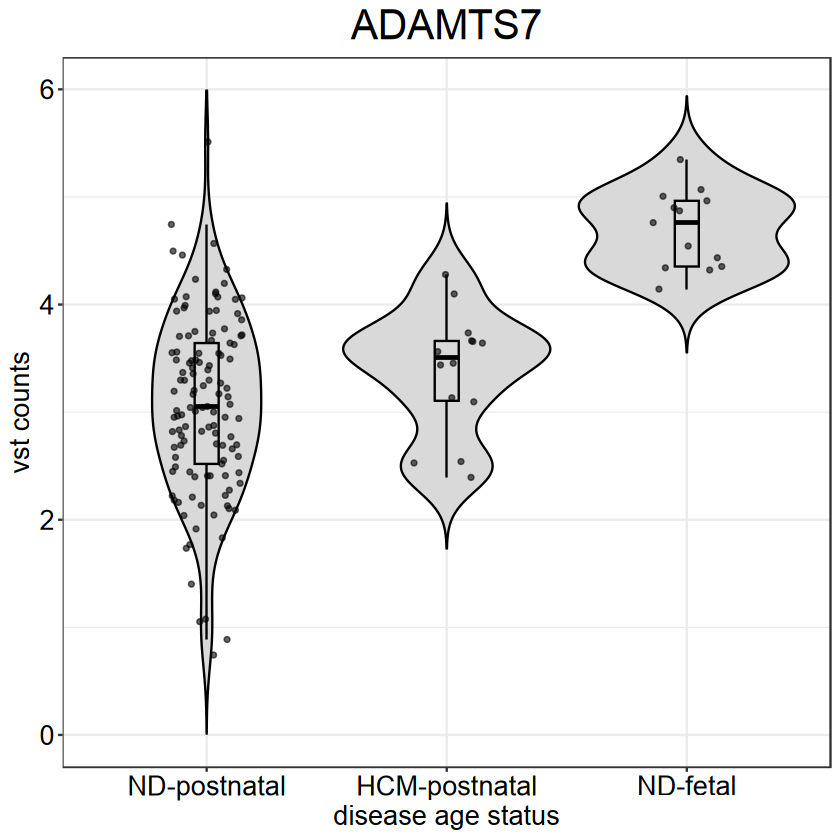

In [9]:
Endo_df$disease_age_status <- factor(Endo_df$disease_age_status, c("ND-postnatal", "HCM-postnatal", "ND-fetal"))

p1 <- ggplot(Endo_df, mapping= aes(x = disease_age_status, y = expression)) +
    geom_violin(trim = FALSE, fill = "grey85", color = "black") +
    geom_boxplot(width = 0.1, fill = "grey85", outlier.shape = NA, color = "black") +
    geom_jitter(width = 0.15, size = 1, alpha = 0.6) +
    theme_bw() +
    labs(x = "disease age status", y = "vst counts", title = gene_name) +
    theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, color = "black"),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black")) + ylim(0, 6)

p1

ggsave(p1, filename = "03B_Endo_ADAMTS7_expression.pdf", width = 8, height = 6)

### Cardiomyocyte DTL

In [10]:
CM_count_matrix <- read.csv("../../../../RNA/aggregated_analysis/v3_pseudobulked_analysis/raw_pseudobulked_matrices/Cardiomyocyte_count_matrix.csv", row.names = 1)
CM_metadata <- read.csv("../../../../RNA/aggregated_analysis/v3_pseudobulked_analysis/raw_pseudobulked_matrices/Cardiomyocyte_metadata.csv", row.names = 1)

In [11]:
CM_dds <- run_filtered_DESeq(count_matrix = CM_count_matrix, metadata = CM_metadata, 
                               metadata_categories = c("ND-fetal", "ND-postnatal", "DCM-postnatal") )

converting counts to integer mode

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]

  Note: levels of factors in the design contain characters other than
  letters, numbers, '_' and '.'. It is recommended (but not required) to use
  only letters, numbers, and delimiters '_' or '.', as these are safe characters
  for column names in R. [This is a message, not a warning or an error]



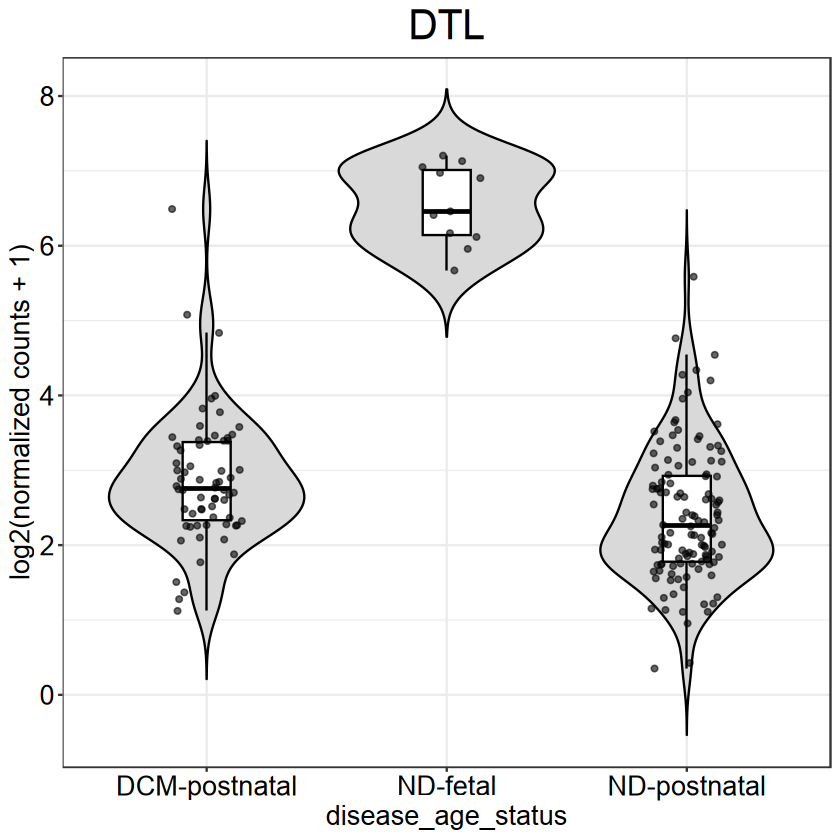

In [12]:
gene_name <- "DTL"
CM_df = plot_gene_violin(CM_dds, gene = gene_name, x_col = "disease_age_status")

Warning message:
“Removed 40 rows containing missing values or values outside the scale range (`geom_violin()`).”
Warning message:
“Removed 40 rows containing missing values or values outside the scale range (`geom_violin()`).”


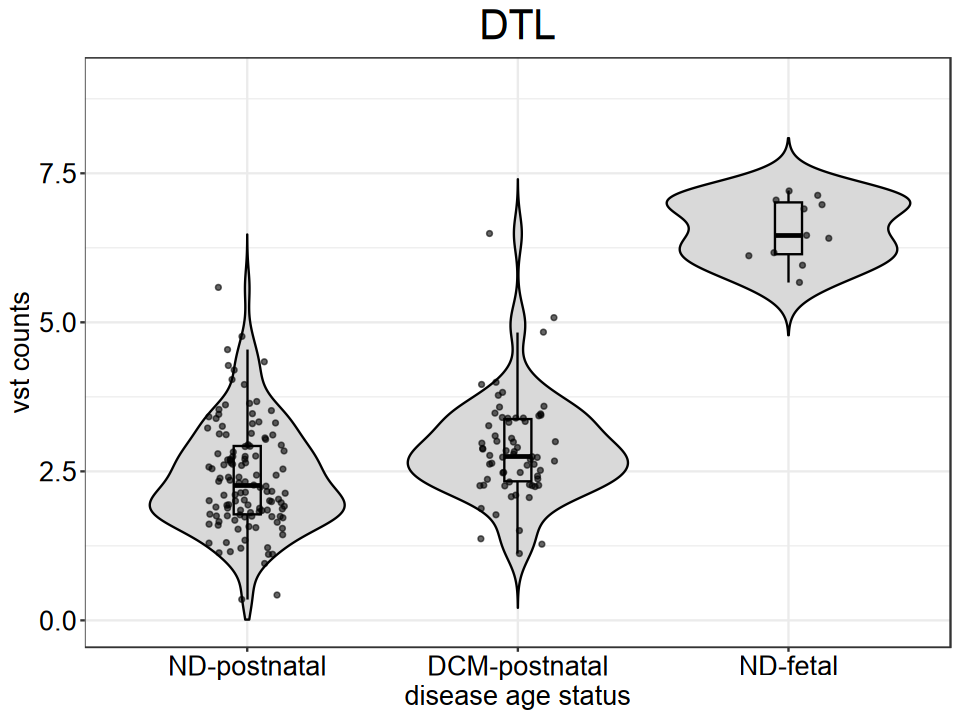

In [13]:
options(repr.plot.width = 8, repr.plot.height = 6)

CM_df$disease_age_status <- factor(CM_df$disease_age_status, c("ND-postnatal", "DCM-postnatal", "ND-fetal"))

p1 <- ggplot(CM_df, mapping= aes(x = disease_age_status, y = expression)) +
    geom_violin(trim = FALSE, fill = "grey85", color = "black") +
    geom_boxplot(width = 0.1, fill = "grey85", outlier.shape = NA, color = "black") +
    geom_jitter(width = 0.15, size = 1, alpha = 0.6) +
    theme_bw() +
    labs(x = "disease age status", y = "vst counts", title = gene_name) +
    theme(legend.text = element_text(size = 16), 
         legend.title = element_text(size = 16, color = "black"), 
         plot.title = element_text(size = 24, hjust = 0.5, color = "black"), 
         axis.title.x = element_text(size = 16, color = "black"),
         axis.title.y = element_text(size = 16, color = "black"),
         axis.text.x = element_text(size = 16, color = "black"),
         axis.text.y = element_text(size = 16, color = "black"),
	 strip.text = element_text(size = 18, color = "black")) + ylim(0, 9)

p1

ggsave(p1, filename = "03B_CM_DTL_expression.pdf", width = 8, height = 6)